# Customer Churn Analysis

This notebook explores telecom customer churn data and builds models to predict customer attrition.

In [8]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_validate, RandomizedSearchCV
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay,
    precision_recall_curve,
    roc_curve,
)
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

sns.set_theme(style="whitegrid")
RANDOM_STATE = 42

In [2]:
df = pd.read_csv("../data/telco_churn.csv")

## Dataset Overview

Before performing deeper analysis, we first examine the structure of the dataset, including the number of features, data types, and potential missing values.

In [3]:
print("Shape:", df.shape)
print("\nData types:")
display(df.dtypes)
print("\nMissing values:")
display(df.isnull().sum().sort_values(ascending=False).head(10))

Shape: (7043, 21)

Data types:


customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object


Missing values:


customerID         0
gender             0
SeniorCitizen      0
Partner            0
Dependents         0
tenure             0
PhoneService       0
MultipleLines      0
InternetService    0
OnlineSecurity     0
dtype: int64

In [75]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [76]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


### Observation

`TotalCharges` often appears as an object column because of blank strings. That needs to be converted before modeling.

In [4]:
df["TotalCharges"] = pd.to_numeric(df["TotalCharges"], errors="coerce")
df["Churn"] = df["Churn"].map({"Yes": 1, "No": 0})

print(df[["tenure", "MonthlyCharges", "TotalCharges", "Churn"]].head())
print("\nMissing values after conversion:")
display(df.isnull().sum()[df.isnull().sum() > 0])

   tenure  MonthlyCharges  TotalCharges  Churn
0       1           29.85         29.85      0
1      34           56.95       1889.50      0
2       2           53.85        108.15      1
3      45           42.30       1840.75      0
4       2           70.70        151.65      1

Missing values after conversion:


TotalCharges    11
dtype: int64

In [79]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

# Exploratory data analysis

## Churn Distribution

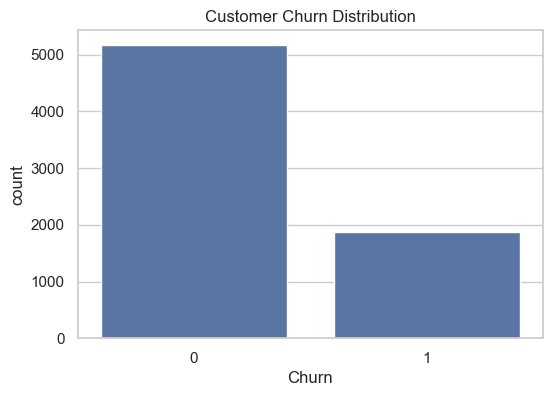

Churn
0    73.463013
1    26.536987
Name: percent, dtype: float64

In [5]:
plt.figure(figsize=(6,4))
sns.countplot(x="Churn", data=df)
plt.title("Customer Churn Distribution")
plt.show()

churn_dist = df["Churn"].value_counts(normalize=True).mul(100).rename("percent")
display(churn_dist)

### Interpretation

The dataset is imbalanced, so accuracy should not be the only evaluation metric. For churn prediction, recall, F1-score, ROC-AUC, and PR-AUC are more informative.

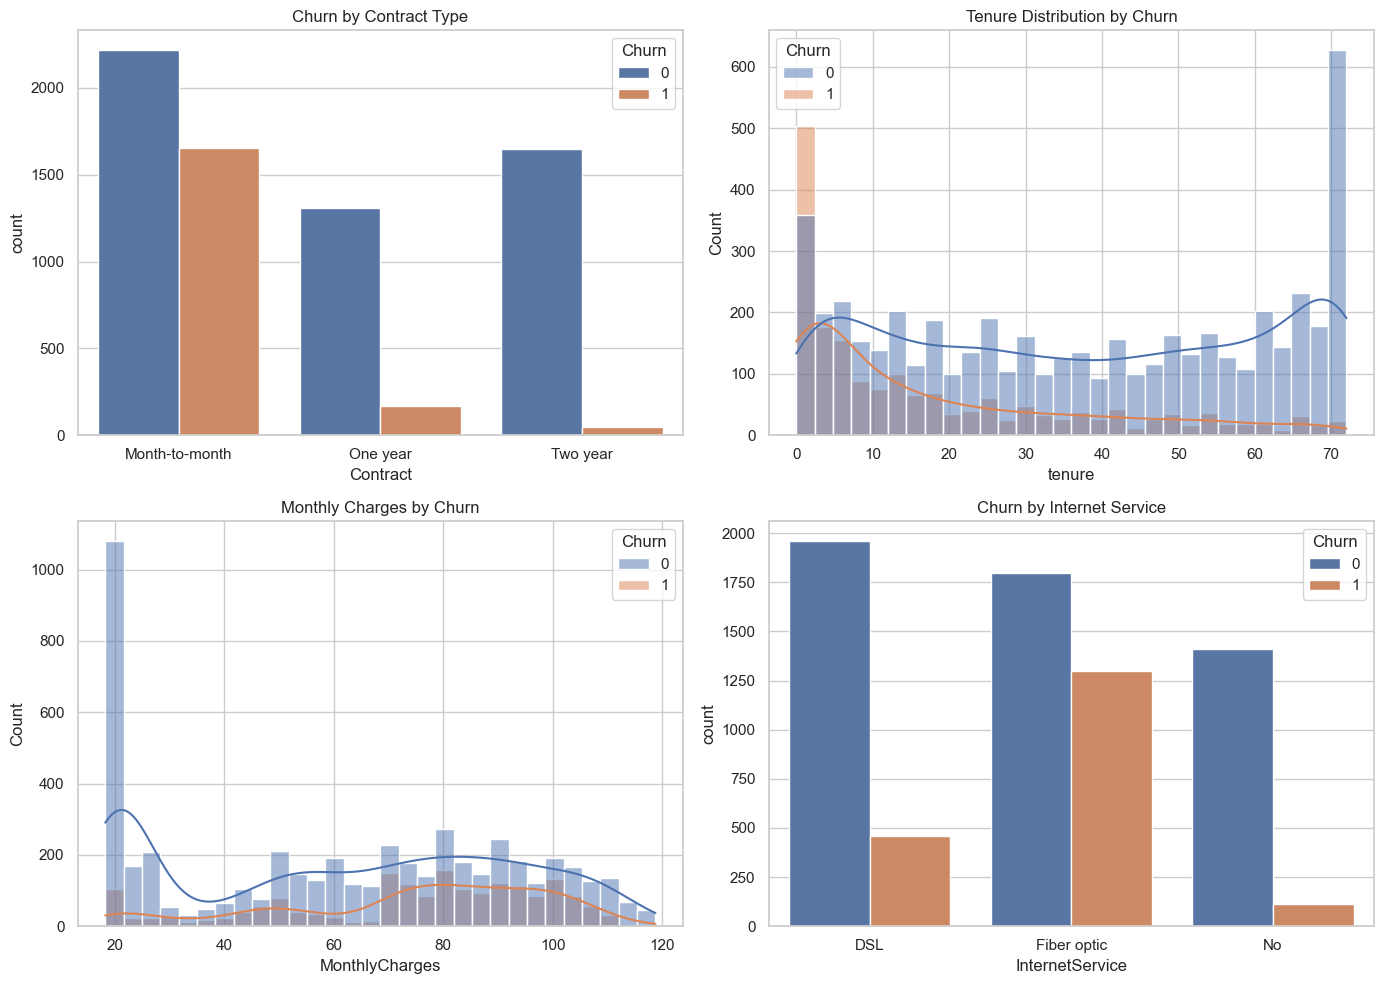

In [6]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

sns.countplot(x="Contract", hue="Churn", data=df, ax=axes[0,0])
axes[0,0].set_title("Churn by Contract Type")

sns.histplot(data=df, x="tenure", hue="Churn", bins=30, kde=True, ax=axes[0,1])
axes[0,1].set_title("Tenure Distribution by Churn")

sns.histplot(data=df, x="MonthlyCharges", hue="Churn", bins=30, kde=True, ax=axes[1,0])
axes[1,0].set_title("Monthly Charges by Churn")

sns.countplot(x="InternetService", hue="Churn", data=df, ax=axes[1,1])
axes[1,1].set_title("Churn by Internet Service")

plt.tight_layout()
plt.show()

## Churn by Payment Method

We analyze whether the payment method used by customers is associated with churn behavior.

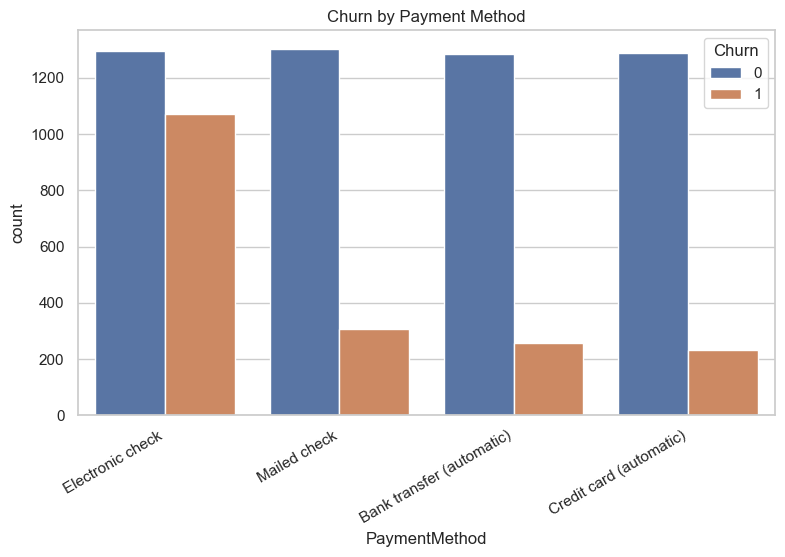

Churn,0,1
PaymentMethod,,
Bank transfer (automatic),83.29,16.71
Credit card (automatic),84.76,15.24
Electronic check,54.71,45.29
Mailed check,80.89,19.11


In [7]:
plt.figure(figsize=(9,5))
sns.countplot(x="PaymentMethod", hue="Churn", data=df)
plt.xticks(rotation=30, ha="right")
plt.title("Churn by Payment Method")
plt.show()

display((pd.crosstab(df["PaymentMethod"], df["Churn"], normalize="index") * 100).round(2))

### EDA summary

- Month-to-month customers churn more
- Lower-tenure customers are higher risk
- Higher monthly charges are associated with more churn
- Fiber optic customers show higher churn
- Electronic check users show higher churn

## Data Preprocessing

In [87]:
df.dtypes

customerID           object
gender               object
SeniorCitizen         int64
Partner              object
Dependents           object
tenure                int64
PhoneService         object
MultipleLines        object
InternetService      object
OnlineSecurity       object
OnlineBackup         object
DeviceProtection     object
TechSupport          object
StreamingTV          object
StreamingMovies      object
Contract             object
PaperlessBilling     object
PaymentMethod        object
MonthlyCharges      float64
TotalCharges         object
Churn                object
dtype: object

In [9]:
X = df.drop(columns=["Churn"]).copy()
y = df["Churn"].copy()

if "customerID" in X.columns:
    X = X.drop(columns=["customerID"])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y
)

numeric_cols = X_train.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = [c for c in X_train.columns if c not in numeric_cols]

numeric_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_pipe = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore")),
])

preprocessor = ColumnTransformer([
    ("num", numeric_pipe, numeric_cols),
    ("cat", categorical_pipe, categorical_cols),
])

print("Numeric columns:", numeric_cols)
print("Number of categorical columns:", len(categorical_cols))

Numeric columns: ['SeniorCitizen', 'tenure', 'MonthlyCharges', 'TotalCharges']
Number of categorical columns: 15


## 5. Baseline models

We use two solid first choices:

- Logistic Regression for a strong, interpretable baseline
- Random Forest for a non-linear ensemble benchmark

In [11]:
models = {
    "logistic_regression": Pipeline([
        ("preprocessor", preprocessor),
        ("model", LogisticRegression(
            max_iter=3000,
            class_weight="balanced",
            random_state=RANDOM_STATE
        )),
    ]),
    "random_forest": Pipeline([
        ("preprocessor", preprocessor),
        ("model", RandomForestClassifier(
            n_estimators=300,
            min_samples_leaf=2,
            class_weight="balanced",
            random_state=RANDOM_STATE,
            n_jobs=-1
        )),
    ]),
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
scoring = {
    "accuracy": "accuracy",
    "precision": "precision",
    "recall": "recall",
    "f1": "f1",
    "roc_auc": "roc_auc",
    "pr_auc": "average_precision"
}

cv_rows = []
for name, model in models.items():
    scores = cross_validate(model, X_train, y_train, scoring=scoring, cv=cv, n_jobs=-1)
    cv_rows.append({
        "model": name,
        "cv_accuracy": scores["test_accuracy"].mean(),
        "cv_precision": scores["test_precision"].mean(),
        "cv_recall": scores["test_recall"].mean(),
        "cv_f1": scores["test_f1"].mean(),
        "cv_roc_auc": scores["test_roc_auc"].mean(),
        "cv_pr_auc": scores["test_pr_auc"].mean(),
    })

cv_results = pd.DataFrame(cv_rows).sort_values("cv_f1", ascending=False).reset_index(drop=True)
cv_results

,model,cv_accuracy,cv_precision,cv_recall,cv_f1,cv_roc_auc,cv_pr_auc
0,logistic_regression,0.747442,0.515791,0.79668,0.626019,0.843818,0.658895
1,random_forest,0.793445,0.605886,0.63548,0.620199,0.837255,0.643953


### Model selection note

Cross-validation gives a more reliable estimate than a single train/test result. It reduces the chance of over-interpreting one lucky split.

### Hyperparameter tuning

In [13]:
log_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", LogisticRegression(
        max_iter=3000,
        class_weight="balanced",
        random_state=RANDOM_STATE
    )),
])

log_search = RandomizedSearchCV(
    estimator=log_pipe,
    param_distributions={
        "model__C": np.logspace(-2, 2, 12),
        "model__solver": ["liblinear", "lbfgs"]
    },
    n_iter=12,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
log_search.fit(X_train, y_train)

best_log_model = log_search.best_estimator_
log_search.best_params_

{'model__solver': 'liblinear', 'model__C': np.float64(0.2848035868435802)}

In [14]:
rf_pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        random_state=RANDOM_STATE,
        n_jobs=-1
    )),
])

rf_search = RandomizedSearchCV(
    estimator=rf_pipe,
    param_distributions={
        "model__n_estimators": [200, 300, 500],
        "model__max_depth": [None, 5, 8, 12, 16],
        "model__min_samples_split": [2, 5, 10],
        "model__min_samples_leaf": [1, 2, 4],
        "model__max_features": ["sqrt", "log2", None],
    },
    n_iter=20,
    scoring="f1",
    cv=5,
    random_state=RANDOM_STATE,
    n_jobs=-1
)
rf_search.fit(X_train, y_train)

best_rf_model = rf_search.best_estimator_
rf_search.best_params_

{'model__n_estimators': 200,
 'model__min_samples_split': 10,
 'model__min_samples_leaf': 1,
 'model__max_features': 'log2',
 'model__max_depth': 8}

### Threshold tuning

Using `0.50` as the cutoff is common, but it is not always best for churn. We tune the threshold on predicted probabilities to improve F1-score.

In [16]:
def evaluate_at_threshold(y_true, y_proba, threshold):
    y_pred = (y_proba >= threshold).astype(int)
    return {
        "threshold": threshold,
        "accuracy": accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred, zero_division=0),
        "recall": recall_score(y_true, y_pred, zero_division=0),
        "f1": f1_score(y_true, y_pred, zero_division=0),
        "roc_auc": roc_auc_score(y_true, y_proba),
        "pr_auc": average_precision_score(y_true, y_proba),
    }

def find_best_threshold(y_true, y_proba):
    thresholds = np.arange(0.10, 0.91, 0.01)
    rows = [evaluate_at_threshold(y_true, y_proba, t) for t in thresholds]
    scores = pd.DataFrame(rows).sort_values("f1", ascending=False).reset_index(drop=True)
    return scores.iloc[0]["threshold"], scores

In [17]:
candidate_models = {
    "tuned_logistic_regression": best_log_model,
    "tuned_random_forest": best_rf_model,
}

test_rows = []

for name, model in candidate_models.items():
    model.fit(X_train, y_train)
    y_proba = model.predict_proba(X_test)[:, 1]
    best_threshold, threshold_table = find_best_threshold(y_test, y_proba)
    row = evaluate_at_threshold(y_test, y_proba, best_threshold)
    row["model"] = name
    test_rows.append(row)

test_results = pd.DataFrame(test_rows).sort_values("f1", ascending=False).reset_index(drop=True)
test_results

,threshold,accuracy,precision,recall,f1,roc_auc,pr_auc,model
0,0.50,0.763203,0.536873,0.779443,0.635808,0.843147,0.641759,tuned_random_forest
1,0.52,0.757524,0.528736,0.788009,0.632846,0.845950,0.637335,tuned_logistic_regression


### Final model evaluation

The best model below is selected based on test-set F1 after threshold tuning.

In [18]:
best_model_name = test_results.loc[0, "model"]

if best_model_name == "tuned_logistic_regression":
    best_model = best_log_model
else:
    best_model = best_rf_model

best_model.fit(X_train, y_train)
y_proba = best_model.predict_proba(X_test)[:, 1]
best_threshold, threshold_scores = find_best_threshold(y_test, y_proba)
y_pred = (y_proba >= best_threshold).astype(int)

print("Best model:", best_model_name)
print("Best threshold:", round(float(best_threshold), 2))
print()
print(classification_report(y_test, y_pred))

Best model: tuned_random_forest
Best threshold: 0.5

              precision    recall  f1-score   support

           0       0.90      0.76      0.82      1294
           1       0.54      0.78      0.64       467

    accuracy                           0.76      1761
   macro avg       0.72      0.77      0.73      1761
weighted avg       0.81      0.76      0.77      1761



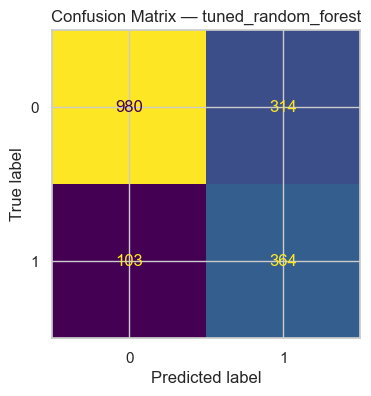

In [19]:
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
fig, ax = plt.subplots(figsize=(5,4))
disp.plot(ax=ax, colorbar=False)
plt.title(f"Confusion Matrix — {best_model_name}")
plt.show()

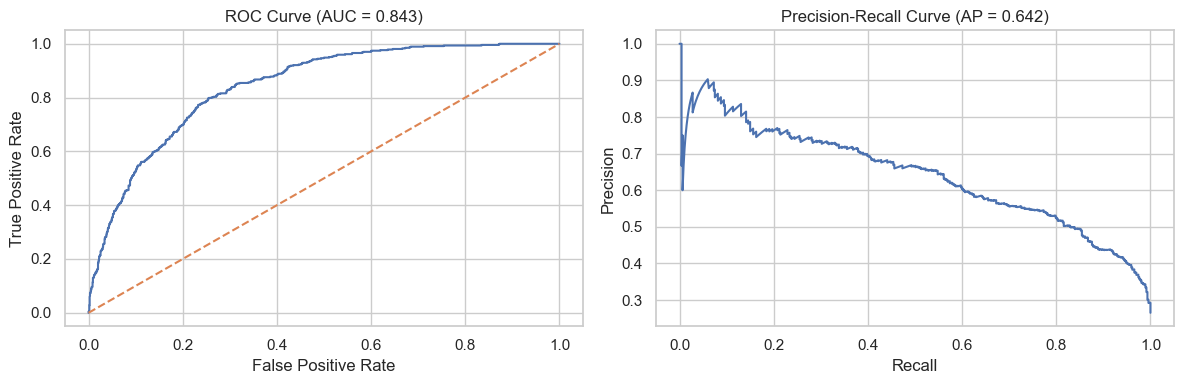

In [20]:
fpr, tpr, _ = roc_curve(y_test, y_proba)
precision, recall, _ = precision_recall_curve(y_test, y_proba)

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(fpr, tpr)
axes[0].plot([0, 1], [0, 1], linestyle="--")
axes[0].set_title(f"ROC Curve (AUC = {roc_auc_score(y_test, y_proba):.3f})")
axes[0].set_xlabel("False Positive Rate")
axes[0].set_ylabel("True Positive Rate")

axes[1].plot(recall, precision)
axes[1].set_title(f"Precision-Recall Curve (AP = {average_precision_score(y_test, y_proba):.3f})")
axes[1].set_xlabel("Recall")
axes[1].set_ylabel("Precision")

plt.tight_layout()
plt.show()

### Model interpretation

This section is more careful than the first version: feature importance here means predictive influence in the model, not direct causation.

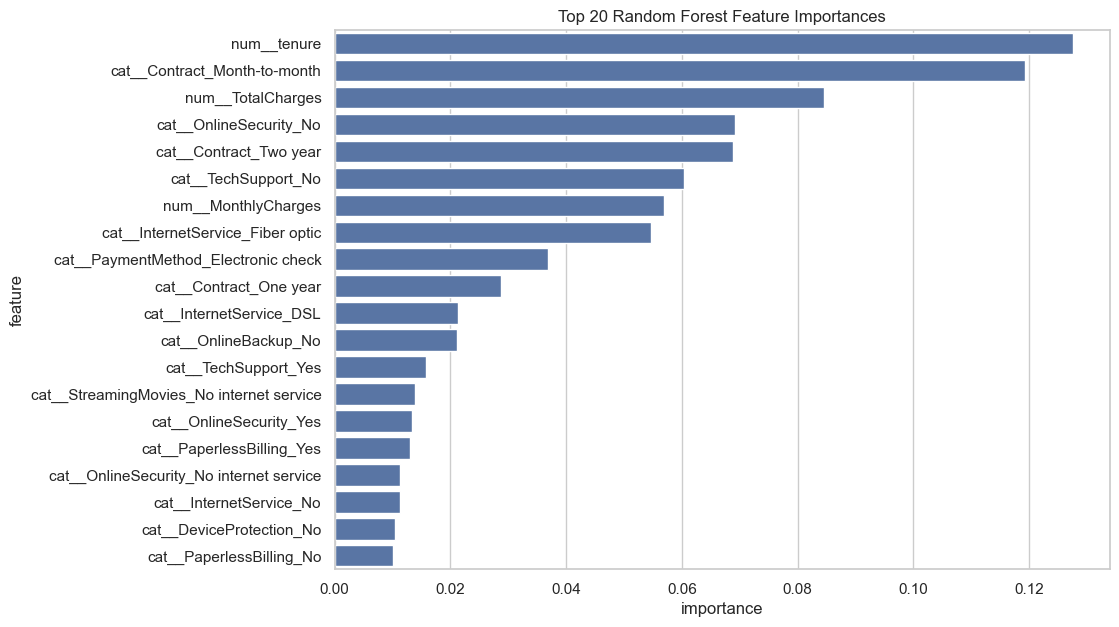

,feature,importance,abs_importance
1,num__tenure,0.127533,0.127533
36,cat__Contract_Month-to-month,0.119223,0.119223
3,num__TotalCharges,0.084482,0.084482
18,cat__OnlineSecurity_No,0.069169,0.069169
38,cat__Contract_Two year,0.068891,0.068891
27,cat__TechSupport_No,0.060332,0.060332
2,num__MonthlyCharges,0.056853,0.056853
16,cat__InternetService_Fiber optic,0.054684,0.054684
43,cat__PaymentMethod_Electronic check,0.036787,0.036787
37,cat__Contract_One year,0.028762,0.028762


In [22]:
feature_names = best_model.named_steps["preprocessor"].get_feature_names_out()
model_obj = best_model.named_steps["model"]

if hasattr(model_obj, "coef_"):
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": model_obj.coef_.ravel()
    })
    importance_df["abs_importance"] = importance_df["importance"].abs()
    importance_df = importance_df.sort_values("abs_importance", ascending=False).head(20)

    plt.figure(figsize=(10, 7))
    sns.barplot(data=importance_df, x="importance", y="feature")
    plt.title("Top 20 Logistic Regression Coefficients")
    plt.show()

else:
    importance_df = pd.DataFrame({
        "feature": feature_names,
        "importance": model_obj.feature_importances_
    })
    importance_df["abs_importance"] = importance_df["importance"].abs()
    importance_df = importance_df.sort_values("abs_importance", ascending=False).head(20)

    plt.figure(figsize=(10, 7))
    sns.barplot(data=importance_df, x="importance", y="feature")
    plt.title("Top 20 Random Forest Feature Importances")
    plt.show()

importance_df.head(20)

Risk scoring for retention campaigns

In [28]:
scored_test = X_test.copy()
scored_test["actual_churn"] = y_test.values
scored_test["predicted_probability"] = y_proba
scored_test["predicted_label"] = y_pred
scored_test["risk_band"] = pd.cut(
    scored_test["predicted_probability"],
    bins=[-0.01, 0.40, 0.70, 1.0],
    labels=["Low", "Medium", "High"]
)

scored_test.sort_values("predicted_probability", ascending=False).head(15)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,...,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,actual_churn,predicted_probability,predicted_label,risk_band
6866,Male,0,No,No,1,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,95.45,95.45,1,0.922612,1,High
4585,Female,1,No,No,1,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,85.05,85.05,1,0.921533,1,High
5474,Female,0,No,No,1,Yes,Yes,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,84.60,84.60,0,0.910616,1,High
3380,Male,1,Yes,No,1,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,95.10,95.10,1,0.909497,1,High
3346,Female,1,No,No,2,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,84.05,186.05,0,0.906839,1,High
6623,Male,1,No,No,1,Yes,Yes,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,76.45,76.45,1,0.904271,1,High
3727,Female,0,No,No,3,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,96.60,291.90,1,0.903889,1,High
2464,Female,0,No,No,1,Yes,Yes,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,77.15,77.15,1,0.902684,1,High
2729,Female,0,No,No,2,Yes,Yes,Fiber optic,No,No,...,Yes,Month-to-month,Yes,Electronic check,85.70,169.80,1,0.901266,1,High
6633,Female,0,No,No,1,Yes,Yes,Fiber optic,No,No,...,No,Month-to-month,Yes,Electronic check,74.50,74.50,1,0.900768,1,High


In [25]:
risk_summary = (
    scored_test.groupby("risk_band", observed=False)
    .agg(
        customers=("predicted_probability", "size"),
        avg_probability=("predicted_probability", "mean"),
        actual_churn_rate=("actual_churn", "mean"),
    )
)

risk_summary

,customers,avg_probability,actual_churn_rate
risk_band,,,
Low,942,0.163269,0.072187
Medium,470,0.557684,0.355319
High,349,0.800695,0.664756
